<div align="right"><i>Peter Norvig<br>October 2018<br>Type annotations 2026</i></div>

# Properly Organized Card Hands

The 538 Riddler [presented](https://fivethirtyeight.com/features/who-will-capture-the-most-james-bonds/) this problem by [Matt Ginsberg](https://www.linkedin.com/in/matthew-ginsberg-8172bb77/) (slightly rephrased):
    
> *When you’re dealt a hand of cards, you want to organize them such that (1) the cards of a given suit are grouped together and (2) the suits alternate color (except that if all the cards are the same color, they don't have to alternate). Numbers don’t matter to you, just suits. You want to achieve this proper organization with a single move, relocating one adjacent block of cards to some other position in your hand. What is the probability that you can accomplish your obsessive goal for the game of pitch, which has 6-card hands? What about for any number of cards from 1 and 13?*

Here are four example 6-card hands, two that can be properly organized with a move of a single block (in parens), and two that can't:

|6-card hand|block to move|result of move|properly organized?|
|---|---|---|---|
|♠️♥️♦️♣️♣️♦️|♠️♥️♦️(♣️♣️♦️)|♠️♥️(♣️♣️♦️)♦️|yes|
|♠️♣️♣️♠️♠️♣️|♠️(♣️♣️)♠️♠️♣️|♠️♠️♠️(♣️♣️)♣️|yes; adjacent ♠️♣️ ok because hand is all black|
|♠️♥️♦️♣️♣️♠️|♠️♥️♦️♣️♣️(♠️)|(♠️)♠️♥️♦️♣️♣️|no; adjacent ♥️♦️ not ok|
|♠️♥️♠️♥️♠️♥️|♠️♥️(♠️)♥️♠️♥️|♠️♥️♥️(♠️)♠️♥️|no; suits not grouped together|


# Brute Force versus Abstraction

The **brute force** approach says:  consider every possible hand and check if it is organizable. There are (52 choose *N*) possible *N*-card hands, which is a lot of hands when *N* = 13.  The **abstraction** approach asks if there is a way in which one abstract hand can represent multiple concrete hands. It turns out there is: the problem states *"Numbers don’t matter,"* so we can abstract from, say,  "seven of spades" to just "a spade." Then there are only 4<sup>*N*</sup> abstract hands. Compare:

|*N*|Concrete Hands|Abstract Hands|
|--|---|---|
|6|20,358,520|4,096|
|13|635,013,559,600|67,108,864|
|*N*|(52 choose *N*) | *N*<sup>4</sup>|

That's a big improvement! Now let's start designing a program to solve the problem:
- There are two red suits and two black suits, so I'll represent the four suits as `'rRbB'`.
- An abstract hand can be represented as a string of suits, for example `'rrBrbr'` is a 6-card hand. 
- The function `deals(N)` will return a [discrete probability distribution](https://en.wikipedia.org/wiki/Probability_distribution) of possible abstract hands of length *N*.
  - For example, `deals(6)` might include the entry `{'rrBrbr': 0.00019}`.
  - With concrete hands, every hand has the same probability, and every card is equally likely to be the next card dealt. But with abstract hands, the probability of the next suit depends on how many cards of that suit have already been dealt. If I've already dealt the 12 cards `'rrrrrrrrrrrr'`, then the probability of the next card being an `'r'` is 1/40, and the probability of it being a `'b'` is 13/40. So as I build up the abstract hands, I'll need to keep track of how many cards of each suit I've already dealt and how many remain.
- I'll use `fractions.Fraction` to get exact arithmetic and `functools.cache` to avoid repeated computations.

In [1]:
from fractions import Fraction
from functools import cache
from itertools import combinations

type Hand = str # A hand is a string of card suits, like 'rrBBrB'
type Probability = Fraction

In [2]:
suits = 'rbRB'

@cache
def deals(N: int) -> dict[Hand, Probability]:
    """A probability distribution of {hand: probability} for all abstract hands of N cards."""
    if N == 0: # There is only one zero-card hand: the empty hand.
        return {'': Fraction(1)}
    else:      # Every way of adding one card to (N-1)-card hands
        P = deals(N - 1)
        return {hand + suit: P[hand] * (13 - hand.count(suit)) / (52 - len(hand))
                for hand in P
                for suit in suits}

In [3]:
deals(1)

{'r': Fraction(1, 4),
 'b': Fraction(1, 4),
 'R': Fraction(1, 4),
 'B': Fraction(1, 4)}

In [4]:
deals(2)

{'rr': Fraction(1, 17),
 'rb': Fraction(13, 204),
 'rR': Fraction(13, 204),
 'rB': Fraction(13, 204),
 'br': Fraction(13, 204),
 'bb': Fraction(1, 17),
 'bR': Fraction(13, 204),
 'bB': Fraction(13, 204),
 'Rr': Fraction(13, 204),
 'Rb': Fraction(13, 204),
 'RR': Fraction(1, 17),
 'RB': Fraction(13, 204),
 'Br': Fraction(13, 204),
 'Bb': Fraction(13, 204),
 'BR': Fraction(13, 204),
 'BB': Fraction(1, 17)}

Is that right? Yes it is. For `deals(1)`, each suit has probability 1/4. For `deals(2)`, the probability of `'BB'` is 1/17, beause the probability of the first `'B'` is 1/4, and when we deal the second card, one `'B'` is gone, so the probability is 12/51, and the product is 1/4 &times; 12/51 = 1/17. The probability of `'BR'` is 1/4 &times; 13/51 = 13/204.

# More Abstraction: Collapsed Hands

Now for a second abstraction: a hand can be **collapsed** by replacing a **run** of cards of the same suit with a single card, so that `'BBBBBrrrrBBBB'` collapses to `'BrB'`. We're interested in grouping cards of the same suit together, so for our purposes any number of cards of the same suit is the same as a single card of that suit. 

In [5]:
type CollapsedHand = str

def collapse(hand: Hand) -> CollapsedHand:
    """Collapse multiple adjacent cards of the same suit into a single card of that suit."""
    return ''.join(hand[i] for i in range(len(hand)) if i == 0 or hand[i] != hand[i - 1])

In [6]:
assert collapse('BBBBBrrrrBBBB') == 'BrB'

# Properly Organized Hands

A hand is considered properly organized if *"(1) the cards of a given suit are grouped together and (2) the suits alternate color,"* with the provision that *"if the cards are all the same color, they don't have to alternate."* In other words: a hand is properly organized if and only if its collapsed hand is properly organized, and a collapsed hand is properly organized if each suit appears only once, and the suits are properly alternating: either all the colors are the same, or suits of the same color don't appear adjacent to each other.

In [7]:
def organized(hand: Hand) -> bool:
    """Properly organized if each suit appears only once, and suits alternate colors."""
    hand1 = collapse(hand)
    return once_each(hand1) and alternating_colors(hand1)

colors = str.lower # e.g. colors('RRbbrrBB') == 'rrbbrrbb'
                                 
def alternating_colors(hand: CollapsedHand) -> bool: 
    """Do the colors of suits in the hand alternate (or is there only one color)?"""
    C = colors(hand)
    return ('bb' not in C and 'rr' not in C) or len(set(C)) == 1

def once_each(hand: CollapsedHand) -> bool: 
    """Do all the suits in a collapsed hand appear just once each?"""
    return len(hand) == len(set(hand))

# Moving Cards

A hand is organizable if it is already organized or if any of the possible moves of a block of consecutive cards makes the hand organized.  I'll throw a `@cache` onto `organizable` so that it won't have to repeat computations.

In [8]:
@cache
def organizable(hand: CollapsedHand) -> bool: 
    """Can this collapsed hand be put into proper organize in one move or less?"""
    return organized(hand) or any(map(organized, moves(hand)))

To find all possible moves, consider every possible start and end position of a block of cards to move, and every possible position to move it too. I'll do that by considering every combination of three index positions (i, j, k) in the hand, with (i < j < k). At first I thought that I would need code for two kinds of moves: moving a block of cards to the right or to the left. But then I realized that if we swap hand[i:j] with hand[j:k], that covers all possible moves: either moving hand[i:j] to the right, or hand[j:k] to the left.

In [9]:
def moves(hand: Hand) -> set[Hand]:
    """All ways of moving a block of cards to get a new hand."""
    return {hand[:i] + hand[j:k] + hand[i:j] + hand[k:] # swap hand[i:j] with hand[j:k]
            for (i, j, k) in combinations(range(len(hand) + 1), 3)}

I'll define `organizable_probability(N)` to give the probability that a random *N*-card hand is organizable. 

In [10]:
def organizable_probability(N: int) -> Probability:
    """What's the probability that an N-card hand is organizable?"""
    P = deals(N)
    return sum(P[hand] for hand in P if organizable(collapse(hand)))

#  Answers for up to 6-Card Hands

Here's the answer for 6 cards:

In [11]:
organizable_probability(6) 

Fraction(51083, 83895)

And an easier-to-read format for everything up to  6 cards:

In [12]:
def report(nums: range) -> None:
    """Show the probability that an N-card hand is organizable, for each N in nums."""
    print('Probability that an N-card hand is organizable:')
    for N in nums:
        P = organizable_probability(N)
        print(f'{N:2}: {float(P):7.2%} or {P}')
        
report(range(7))

Probability that an N-card hand is organizable:
 0: 100.00% or 1
 1: 100.00% or 1
 2: 100.00% or 1
 3: 100.00% or 1
 4: 100.00% or 1
 5:  85.24% or 213019/249900
 6:  60.89% or 51083/83895


# Getting to 13-Card Hands

So far so good, but 4<sup>13</sup> = 67,108,864 is a big number; `organizable_probability(13)` would take several minutes to run. But I discovered three key properties that can speed things up. These are genral properties that appear in many combinatoric problems:

- **Upper bounds:** We know that a properly organized collapsed hand can have at most 4 characters. But a move can reduce the number of characters by at most 3:  one can be reduced when we remove the block of cards (if the cards on either side of the block are the same), and up to two more can be reduced when we re-insert the block (if the left and/or right ends of the block match the surrounding suits). That means that the upper bound on the length of an organizable collapsed hand is 7 characters. Here's an example of moving a block (in parens) to reduce the number of runs from 7 to 4:

|dealt hand|block to move|result of move|properly organized?|
|---|---|---|---|
|♥️♣️♦️♠️♥️♣️♠️|♥️♣️♦️♠️(♥️♣️)♠️|♥️(♥️♣️)♣️♦️♠️♠️|yes, collapses to ♥️♣️♦️♠️|

       
- **Monotonicity:** Adding an additional card to an unorganizable collapsed hand can't make it organizable. To see that, take an unorganized collapsed hand, and see what happens if you take the extra card and insert it anywhere in the CollapsedHand. If the CollapsedHand was unorganized because it repeats a suit, adding a suit can't fix that. If it was unorganized because suits of the same color are adjacent, then adding a suit of the other color *could* fix that: `'bBR'` could be fixed by adding an 'r' at the end and moving it to get `'brBR'`. But here's the catch: `'bBR'` is not unorganizable. And if we are going to insert a new suit between two others, that means that the original CollapsedHand must have had at most three suits (because when we add one, we can't get more than four suits in an organized CollapsedHand), and *every* three-suit CollapsedHand is organizable.

- **Symmetry:** Each of the four suits plays the same role in the game; they are symmetric. Thus, for the first card in a hand, we can arbitrarily choose one suit, say 'B', and not consider any of the other suits. Starting with any of the other three suits would give us the same probability, so by only considering 'B' as the first card we get the same answer with 1/4 the computation.

The property of monotonicity means that we can use a strategy where we only keep track of the organizable hands, (not all possible hands), and we stop building onto a hand when it is unorganizable. I'll define  `organizable_deals(N)` to return a {hand: probability} dict of just the organizable hands:

In [13]:
@cache
def organizable_deals(N: int) -> dict[Hand, Probability]:
    """A dict of {hand: probability} for all organizable hands of length N."""
    if N == 0:   # There is only one zero-card hand: the empty hand.
        return {'': Fraction(1)}
    elif N == 1: # Use symmetry; only consider one suit for first card
        return {'B': Fraction(1)}
    else:        # Every way of adding one card to (N-1)-card hands to make organizable hands
        P = organizable_deals(N - 1)
        return {hand + suit: P[hand] * (13 - hand.count(suit)) / (52 - len(hand))
                for hand in P
                for suit in suits
                if organizable(collapse(hand + suit))}

Now I'll redefine `organizable` to take advantage of the 7-character upper bound, and `organizable_probability` to quickly sum the probabilities of the organizable deals:

In [14]:
@cache
def organizable(hand: CollapsedHand) -> bool: 
    """Can this collapsed hand be put into proper organize in one move?"""
    return len(hand) <= 7 and (organized(hand) or any(map(organized, moves(hand))))

def organizable_probability(N: int) -> Probability:
    """What's the probability that an N-card hand is organizable?"""
    return sum(organizable_deals(N).values())

# Final Answer

We're finaly ready to go up to *N* = 13:

In [15]:
%time report(range(14))

Probability that an N-card hand is organizable:
 0: 100.00% or 1
 1: 100.00% or 1
 2: 100.00% or 1
 3: 100.00% or 1
 4: 100.00% or 1
 5:  85.24% or 213019/249900
 6:  60.89% or 51083/83895
 7:  37.32% or 33606799/90047300
 8:  20.18% or 29210911/144718875
 9:   9.86% or 133194539/1350709500
10:   4.43% or 367755247/8297215500
11:   1.86% or 22673450197/1219690678500
12:   0.74% or 1751664923/238130084850
13:   0.28% or 30785713171/11112737293000
CPU times: user 491 ms, sys: 6.36 ms, total: 497 ms
Wall time: 497 ms


Not bad. We got exact answers for all *N* up to 13 in a half second total run time.

# Inspecting the Cache

Let's look at the cache for  `organizable(hand)`:

In [16]:
organizable.cache_info()

CacheInfo(hits=359627, misses=385, maxsize=None, currsize=385)

So `hhits=359627` menas that that's the number of hands we considered, but only 385 were unique distinct collapsed hands. And once we hit *N* = 7, we've seen all the collapsed hands we're ever going to see. From *N* = 8 and up, almost all the computation goes into computing the probability of each hand, and collapsing each hand, not into deciding which are organizeable.

Now let's look at the number of hands considered by `deals(N)` compared to `organizable_deals(N)`:

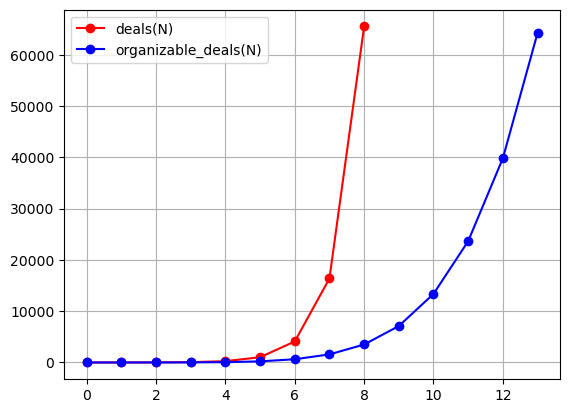

In [17]:
import matplotlib.pyplot as plt

Ns = range(9)
plt.plot(Ns, [len(deals(N)) for N in Ns], 'ro-', label='deals(N)')
Ns = range(14)
plt.plot(Ns, [len(organizable_deals(N)) for N in Ns], 'bo-', label='organizable_deals(N)')
plt.grid(True)
plt.legend();

The number of <span style="color:red">deals</span> grows with 4<sup>*N*</sup>, but the number of <span style="color:blue">organizable deals</span> less than doubles each step; it is growing slower than 2<sup>*N*</sup>.

# Unit Tests

To gain confidence in this project, here are some unit tests. Before declaring my answers definitively correct, I would want a lot more tests, and some independent code reviews.

In [18]:
def test():
    assert deals(1) == {'B': 1/4, 'R': 1/4, 'b': 1/4, 'r': 1/4}
    for N in range(7):
        assert len(deals(N)) == 4 ** N       # A deal has all 4**N abstract hands
        assert sum(deals(N).values()) == 1   # The sum of the probabilities must be 1.
    assert organizable_deals(1) == {'B': Fraction(1, 1)}
    assert organized('BBBBBrrrrBBBB') is False
    assert organized('BBBBBrrrrRRRR') is False
    assert organized('BBBbbr') is False # Bb
    assert organized('BBBbbrB') is False # two B's
    assert organized('BBBbbb') 
    assert organized('BBBbbbB') is False # two B's
    assert organized('BBBBBrrrrbbbb')
    assert organized('BBBbbb')
    assert organized('BBBbbb')
    assert organized('BBBRbb')
    assert organized('BBBbbR') is False
    assert organized('BBBrBB') is False
    assert organized('BBrrBR') is False
    assert colors('BBBBBrrrrbbbb') == 'bbbbbrrrrbbbb'
    assert once_each('Bb')
    assert once_each('BbRr')
    assert once_each('BbRB') is False
    assert alternating_colors('Brb')
    assert alternating_colors('BbR') is False
    assert alternating_colors('BBb')
    assert collapse('BBBBBrrrrBBBB') == 'BrB'
    assert collapse('brBBrrRR') == 'brBrR'
    assert collapse('bbbbBBBrrr') == 'bBr'
    assert moves('bRb') == {'Rbb', 'bbR'}
    assert moves('bRB') == {'BbR', 'RBb', 'RbB', 'bBR'}
    assert organizable('bBr') # move 'r' between 'bB'
    assert organizable('bBrbRBr') # move 'bRB' after first 'b' to get 'bbRBBrr'
    assert organizable('bBrbRBrb') is False
    
    return True

test()

True